In [1]:
import pathlib

import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

In [2]:
input_file_path = pathlib.Path(
    "../results_of_memory_profiling/concatenated_results.parquet"
).resolve(strict=True)
df = pd.read_parquet(input_file_path)
df.head()

,num_of_features,num_of_cells_per_well,num_of_wells,num_of_features_retained,percent_of_features_retained,rss_MB,vms_MB,shared_MB,text_MB,lib_MB,data_MB,dirty_MB,total_MB,elapsed_time
0,1000,1000,1000,1001,100.0,62.406250,278.164062,2.4375,0.0,0.0,276.894531,0.0,62.406250,183.545341
1,1000,1000,100,1001,100.0,770.605469,982.425781,2.4375,0.0,0.0,981.156250,0.0,770.605469,8.050165
2,1000,1000,1,1001,100.0,29.089844,240.835938,2.6250,0.0,0.0,239.566406,0.0,29.089844,0.278377
3,1000,100,1000,1001,100.0,771.007812,982.390625,2.6250,0.0,0.0,981.121094,0.0,771.007812,8.122283
4,1000,100,100,1001,100.0,82.769531,294.777344,2.6250,0.0,0.0,293.507812,0.0,82.769531,0.819083


In [3]:
df["total_GB"] = df["total_MB"] / 1024
df["elapsed_time_minutes"] = df["elapsed_time"] / 60
df["total_cell_count"] = df["num_of_cells_per_well"] * df["num_of_wells"]
# make a column that is a tuple of the two columns
df["profile_shape"] = (
    df["num_of_features"].astype(str) + "_" + df["total_cell_count"].astype(str)
)
df.head()

,num_of_features,num_of_cells_per_well,num_of_wells,num_of_features_retained,percent_of_features_retained,rss_MB,vms_MB,shared_MB,text_MB,lib_MB,data_MB,dirty_MB,total_MB,elapsed_time,total_GB,elapsed_time_minutes,total_cell_count,profile_shape
0,1000,1000,1000,1001,100.0,62.406250,278.164062,2.4375,0.0,0.0,276.894531,0.0,62.406250,183.545341,0.060944,3.059089,1000000,1000_1000000
1,1000,1000,100,1001,100.0,770.605469,982.425781,2.4375,0.0,0.0,981.156250,0.0,770.605469,8.050165,0.752544,0.134169,100000,1000_100000
2,1000,1000,1,1001,100.0,29.089844,240.835938,2.6250,0.0,0.0,239.566406,0.0,29.089844,0.278377,0.028408,0.004640,1000,1000_1000
3,1000,100,1000,1001,100.0,771.007812,982.390625,2.6250,0.0,0.0,981.121094,0.0,771.007812,8.122283,0.752937,0.135371,100000,1000_100000
4,1000,100,100,1001,100.0,82.769531,294.777344,2.6250,0.0,0.0,293.507812,0.0,82.769531,0.819083,0.080830,0.013651,10000,1000_10000


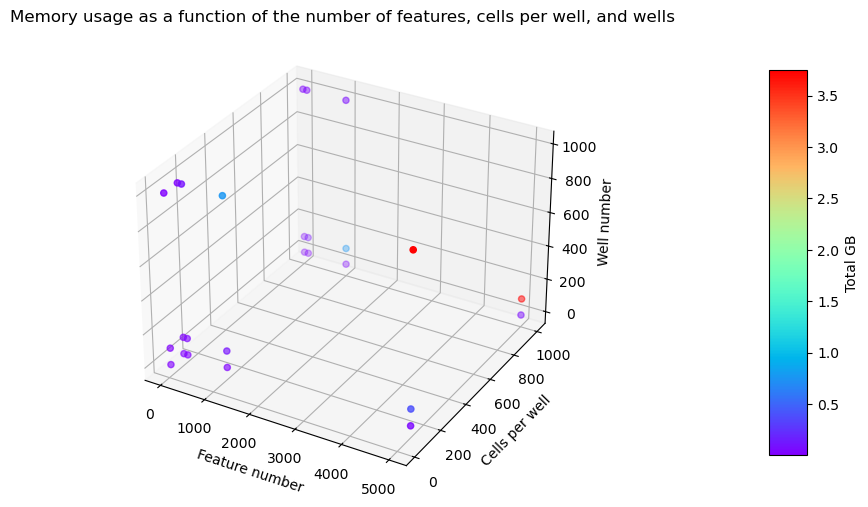

In [4]:
# 3d plot of the data

fig = plt.figure()
fig.set_size_inches(10, 10)
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    data=df,
    xs="num_of_features",
    ys="num_of_cells_per_well",
    zs="num_of_wells",
    c="total_GB",
    cmap="rainbow",
)


ax.set_xlabel("Feature number")
ax.set_ylabel("Cells per well")
ax.set_zlabel("Well number")
# add color bar
cbar = plt.colorbar(
    ax.collections[0],
    ax=ax,
    orientation="vertical",
    location="right",
    shrink=0.5,
    aspect=10,
    pad=0.25,
)
cbar.set_label("Total GB")

plt.title(
    "Memory usage as a function of the number of features, cells per well, and wells"
)

plt.show()

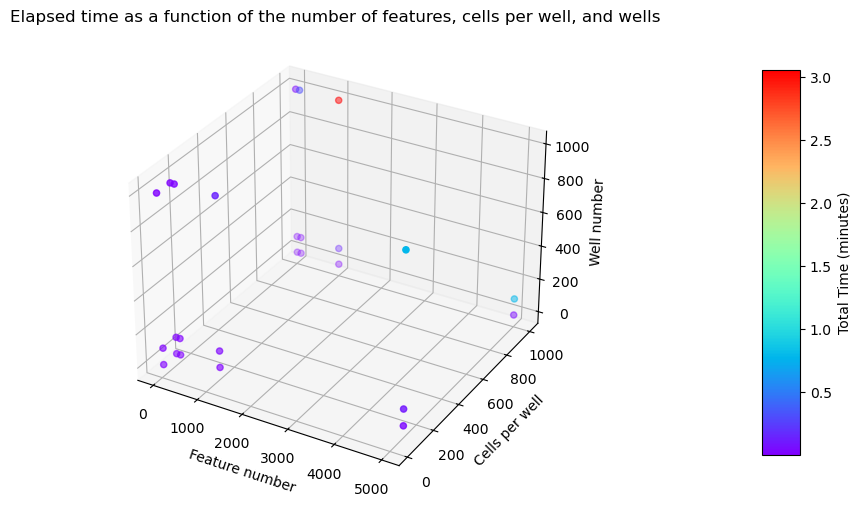

In [5]:
# 3d plot of the data
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
fig.set_size_inches(10, 10)
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    data=df,
    xs="num_of_features",
    ys="num_of_cells_per_well",
    zs="num_of_wells",
    c="elapsed_time_minutes",
    cmap="rainbow",
)


ax.set_xlabel("Feature number")
ax.set_ylabel("Cells per well")
ax.set_zlabel("Well number")
# add color bar
cbar = plt.colorbar(
    ax.collections[0],
    ax=ax,
    orientation="vertical",
    location="right",
    shrink=0.5,
    aspect=10,
    pad=0.25,
)
cbar.set_label("Total Time (minutes)")
plt.title(
    "Elapsed time as a function of the number of features, cells per well, and wells"
)


plt.show()

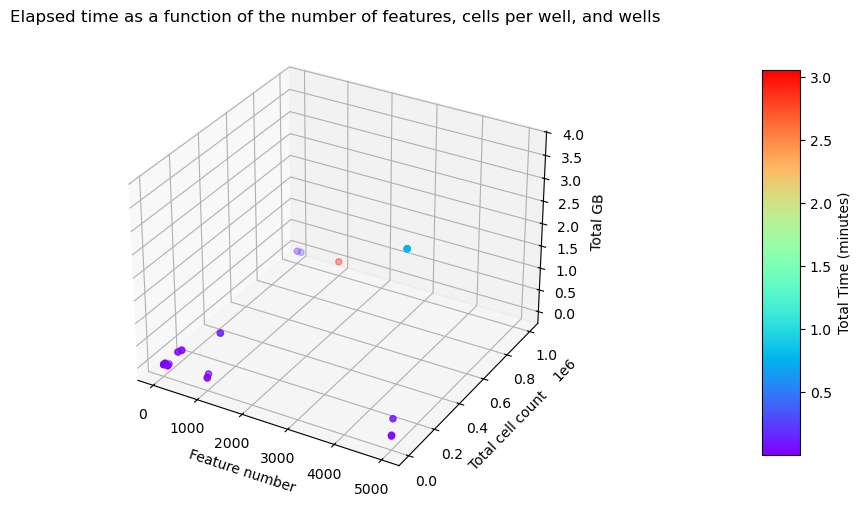

In [7]:
# 3d plot of the data
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
fig.set_size_inches(10, 10)
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    data=df,
    xs="num_of_features",
    ys="total_cell_count",
    zs="total_GB",
    c="elapsed_time_minutes",
    cmap="rainbow",
)


ax.set_xlabel("Feature number")
ax.set_ylabel("Total cell count")
ax.set_zlabel("Total GB")
# add color bar
cbar = plt.colorbar(
    ax.collections[0],
    ax=ax,
    orientation="vertical",
    location="right",
    shrink=0.5,
    aspect=10,
    pad=0.25,
)
cbar.set_label("Total Time (minutes)")
plt.title(
    "Elapsed time as a function of the number of features, cells per well, and wells"
)


plt.show()